In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.graphics.tsaplots import plot_acf

DATA_PATH = "../data/mdm2_data_files/master_mobility_model_with_lags.csv"

df = pd.read_csv(DATA_PATH)
df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")

print(df.shape)
print(df.columns.tolist())

/Users/shavarshmelikyan/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/shavarshmelikyan/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


(378373, 33)
['sensor_id', 'datetime', 'date_only', 'hour', 'dow', 'is_weekend', 'week', 'month', 'year', 'longitude', 'latitude', 'cluster_geo', 'ward_name', 'ped', 'cyc', 'car', 'active', 'solar_altitude_deg', 'light_class', 'Dark', 'temp_c', 'wind_ms', 'rain_mm', 'cctv_300m', 'safety_after_dark_pct', 'safety_scaled', 'weekday', 'ped_lag1', 'ped_lag24', 'cyc_lag1', 'cyc_lag24', 'active_lag1', 'active_lag24']


In [2]:
# daily periodicity
df["sin_hour_1"] = np.sin(2 * np.pi * df["hour"] / 24)
df["cos_hour_1"] = np.cos(2 * np.pi * df["hour"] / 24)

df["sin_hour_2"] = np.sin(4 * np.pi * df["hour"] / 24)
df["cos_hour_2"] = np.cos(4 * np.pi * df["hour"] / 24)

# weekly periodicity
df["sin_week"] = np.sin(2 * np.pi * df["week"] / 52)
df["cos_week"] = np.cos(2 * np.pi * df["week"] / 52)

In [4]:
def fit_ts_glm(data, outcome, lag1, lag24):
    formula = f"""
    {outcome} ~
    {lag1}
    + {lag24}
    + sin_hour_1
    + cos_hour_1
    + sin_hour_2
    + cos_hour_2
    + sin_week
    + cos_week
    + C(dow)
    + is_weekend
    + C(cluster_geo)
    + temp_c
    + wind_ms
    + rain_mm
    + Dark
    + Dark:C(cluster_geo)
    + safety_scaled
    """

    model_cols = [
        outcome,
        lag1,
        lag24,
        "sin_hour_1",
        "cos_hour_1",
        "sin_hour_2",
        "cos_hour_2",
        "sin_week",
        "cos_week",
        "dow",
        "is_weekend",
        "cluster_geo",
        "temp_c",
        "wind_ms",
        "rain_mm",
        "Dark",
        "safety_scaled",
        "sensor_id"
    ]

    df_m = data[model_cols].dropna().reset_index(drop=True)

    model = smf.glm(
        formula=formula,
        data=df_m,
        family=sm.families.NegativeBinomial()
    ).fit(
        cov_type="cluster",
        cov_kwds={"groups": df_m["sensor_id"].values}
    )

    return model, df_m

In [5]:
cyc_model, cyc_df = fit_ts_glm(
    df,
    outcome="cyc",
    lag1="cyc_lag1",
    lag24="cyc_lag24"
)

print("CYCLISTS MODEL")
print("Rows used:", len(cyc_df))
print("Unique sensors:", cyc_df["sensor_id"].nunique())
print(cyc_model.summary())

CYCLISTS MODEL
Rows used: 376901
Unique sensors: 46
                 Generalized Linear Model Regression Results                  
Dep. Variable:                    cyc   No. Observations:               376901
Model:                            GLM   Df Residuals:                   376877
Model Family:        NegativeBinomial   Df Model:                           23
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.2511e+06
Date:                Thu, 12 Mar 2026   Deviance:                   5.0020e+05
Time:                        10:17:00   Pearson chi2:                 7.46e+05
No. Iterations:                    43   Pseudo R-squ. (CS):             0.7141
Covariance Type:              cluster                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------

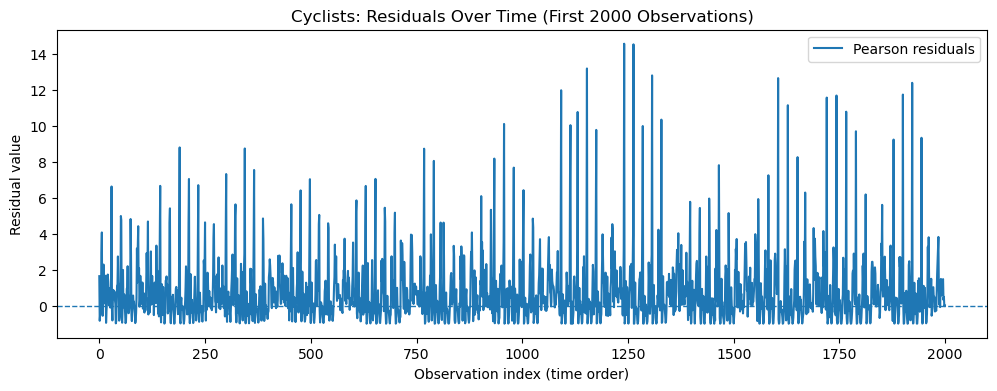

<Figure size 1000x500 with 0 Axes>

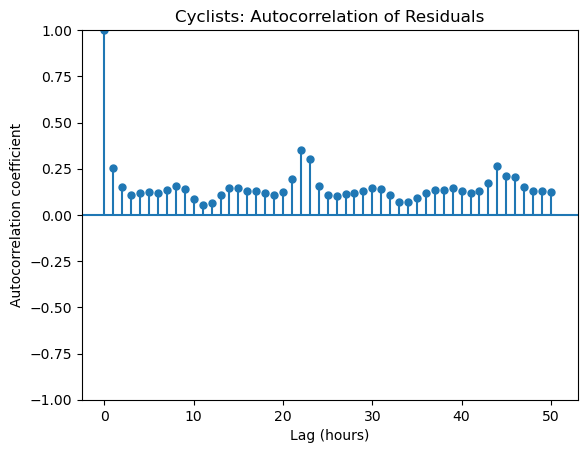

Cyclists baseline-cluster darkness effect (%): -25.990744926003817
Cyclists darkness effect by cluster (%):
{'Cluster 0': -25.990744926003817, 'Cluster 1': -2.056644057455448, 'Cluster 2': -38.67765085337675}


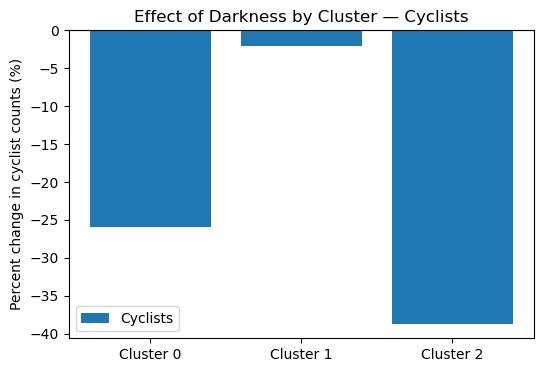

In [6]:
# residuals
cyc_df["resid"] = cyc_model.resid_pearson

plt.figure(figsize=(12,4))
plt.plot(cyc_df["resid"].values[:2000], label="Pearson residuals")
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Observation index (time order)")
plt.ylabel("Residual value")
plt.title("Cyclists: Residuals Over Time (First 2000 Observations)")
plt.legend()
plt.show()

# acf
plt.figure(figsize=(10,5))
plot_acf(cyc_df["resid"], lags=50)
plt.xlabel("Lag (hours)")
plt.ylabel("Autocorrelation coefficient")
plt.title("Cyclists: Autocorrelation of Residuals")
plt.show()

# baseline darkness effect
cyc_dark_coef = cyc_model.params["Dark"]
cyc_dark_effect = (np.exp(cyc_dark_coef) - 1) * 100
print("Cyclists baseline-cluster darkness effect (%):", cyc_dark_effect)

# darkness effect by cluster
coef = cyc_model.params

dark0 = coef["Dark"]
dark1 = coef["Dark"] + coef.get("Dark:C(cluster_geo)[T.1]", 0)
dark2 = coef["Dark"] + coef.get("Dark:C(cluster_geo)[T.2]", 0)

cyc_effects = {
    "Cluster 0": (np.exp(dark0)-1)*100,
    "Cluster 1": (np.exp(dark1)-1)*100,
    "Cluster 2": (np.exp(dark2)-1)*100
}

print("Cyclists darkness effect by cluster (%):")
print(cyc_effects)

plt.figure(figsize=(6,4))
plt.bar(cyc_effects.keys(), cyc_effects.values(), label="Cyclists")
plt.axhline(0)
plt.ylabel("Percent change in cyclist counts (%)")
plt.title("Effect of Darkness by Cluster — Cyclists")
plt.legend()
plt.show()

In [7]:
active_model, active_df = fit_ts_glm(
    df,
    outcome="active",
    lag1="active_lag1",
    lag24="active_lag24"
)

print("ACTIVE TRAVEL MODEL")
print("Rows used:", len(active_df))
print("Unique sensors:", active_df["sensor_id"].nunique())
print(active_model.summary())

ACTIVE TRAVEL MODEL
Rows used: 376901
Unique sensors: 46
                 Generalized Linear Model Regression Results                  
Dep. Variable:                 active   No. Observations:               376901
Model:                            GLM   Df Residuals:                   376877
Model Family:        NegativeBinomial   Df Model:                           23
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.8498e+06
Date:                Thu, 12 Mar 2026   Deviance:                   6.1805e+05
Time:                        10:18:21   Pearson chi2:                 5.53e+05
No. Iterations:                    41   Pseudo R-squ. (CS):             0.8093
Covariance Type:              cluster                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------

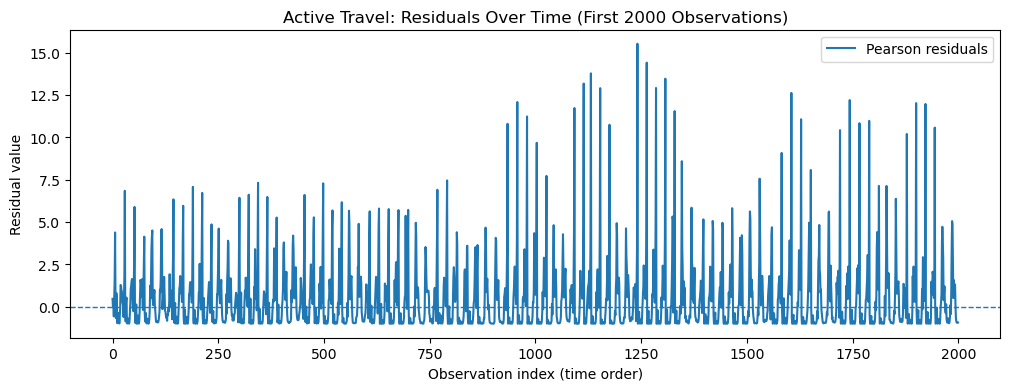

<Figure size 1000x500 with 0 Axes>

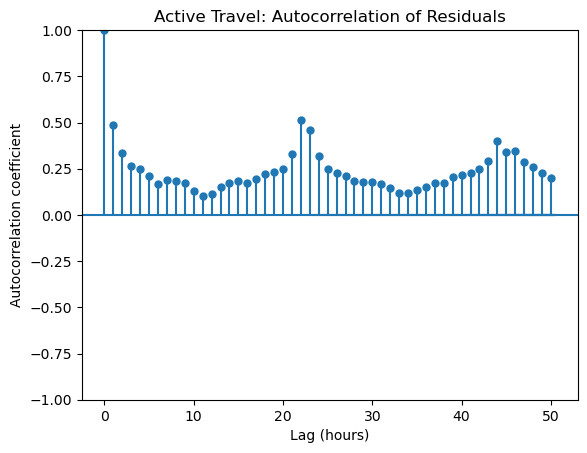

Active baseline-cluster darkness effect (%): -55.23941834105837
Active travel darkness effect by cluster (%):
{'Cluster 0': -55.23941834105837, 'Cluster 1': -41.38986773471807, 'Cluster 2': -34.68497196445974}


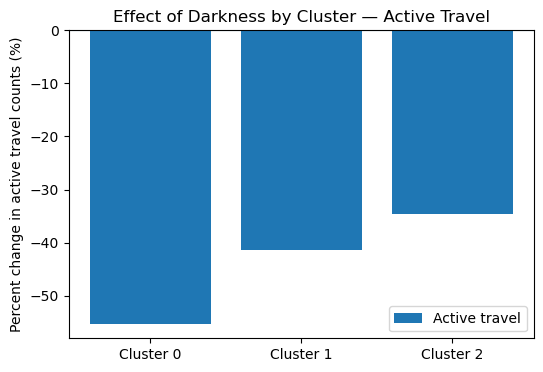

In [8]:
# residuals
active_df["resid"] = active_model.resid_pearson

plt.figure(figsize=(12,4))
plt.plot(active_df["resid"].values[:2000], label="Pearson residuals")
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Observation index (time order)")
plt.ylabel("Residual value")
plt.title("Active Travel: Residuals Over Time (First 2000 Observations)")
plt.legend()
plt.show()

# acf
plt.figure(figsize=(10,5))
plot_acf(active_df["resid"], lags=50)
plt.xlabel("Lag (hours)")
plt.ylabel("Autocorrelation coefficient")
plt.title("Active Travel: Autocorrelation of Residuals")
plt.show()

# baseline darkness effect
active_dark_coef = active_model.params["Dark"]
active_dark_effect = (np.exp(active_dark_coef) - 1) * 100
print("Active baseline-cluster darkness effect (%):", active_dark_effect)

# darkness effect by cluster
coef = active_model.params

dark0 = coef["Dark"]
dark1 = coef["Dark"] + coef.get("Dark:C(cluster_geo)[T.1]", 0)
dark2 = coef["Dark"] + coef.get("Dark:C(cluster_geo)[T.2]", 0)

active_effects = {
    "Cluster 0": (np.exp(dark0)-1)*100,
    "Cluster 1": (np.exp(dark1)-1)*100,
    "Cluster 2": (np.exp(dark2)-1)*100
}

print("Active travel darkness effect by cluster (%):")
print(active_effects)

plt.figure(figsize=(6,4))
plt.bar(active_effects.keys(), active_effects.values(), label="Active travel")
plt.axhline(0)
plt.ylabel("Percent change in active travel counts (%)")
plt.title("Effect of Darkness by Cluster — Active Travel")
plt.legend()
plt.show()

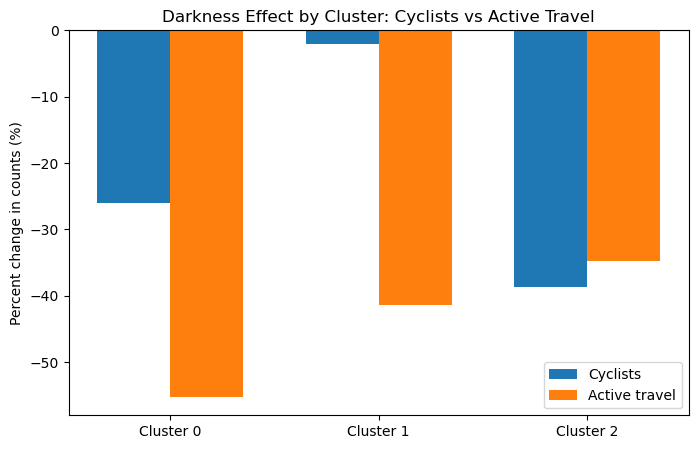

In [9]:
clusters = ["Cluster 0", "Cluster 1", "Cluster 2"]
x = np.arange(len(clusters))
width = 0.35

cyc_vals = [cyc_effects[c] for c in clusters]
active_vals = [active_effects[c] for c in clusters]

plt.figure(figsize=(8,5))
plt.bar(x - width/2, cyc_vals, width, label="Cyclists")
plt.bar(x + width/2, active_vals, width, label="Active travel")

plt.axhline(0)
plt.xticks(x, clusters)
plt.ylabel("Percent change in counts (%)")
plt.title("Darkness Effect by Cluster: Cyclists vs Active Travel")
plt.legend()
plt.show()

### Cyclists model results

The time-series negative binomial GLM was estimated using hourly cyclist counts from 46 sensors across Bristol.  
The model includes temporal structure (lag terms and Fourier cycles), weather variables, cluster effects, and darkness interactions.

The baseline darkness coefficient corresponds to the effect of darkness in the reference cluster (Cluster 0).

Estimated baseline darkness effect:

- **−26% change in cyclist counts during darkness**

This means that, holding other variables constant, cyclist counts decrease by approximately **26% when conditions change from daylight to darkness** in the baseline cluster.

Cluster interactions show that the darkness effect differs across spatial clusters.

### Darkness effect by cluster (cyclists)

The estimated effect of darkness varies across spatial clusters:

| Cluster | Darkness effect |
|-------|----------------|
| Cluster 0 | −26% |
| Cluster 1 | −2% |
| Cluster 2 | −39% |

These results suggest that the deterrent effect of darkness is not uniform across Bristol.

In Cluster 1, cycling activity appears largely unaffected by darkness, potentially indicating commuter cycling corridors where travel is necessary regardless of lighting conditions.

Cluster 2 shows the strongest decline in cycling activity after dark.

### Active travel model (pedestrians + cyclists)

A second model was estimated using **active travel counts**, defined as the sum of pedestrian and cyclist observations.

The model structure is identical to the cyclist model and includes:

- lag terms capturing short-term temporal dependence
- Fourier terms modelling daily and weekly cycles
- weather variables
- spatial cluster effects
- darkness interactions

The model explains a substantial proportion of variation in active travel counts:

**Pseudo-R² ≈ 0.81**

This indicates that the included predictors capture most of the systematic variation in active travel behaviour.

### Darkness effect by cluster (active travel)

The estimated darkness effects for total active travel are:

| Cluster | Darkness effect |
|-------|----------------|
| Cluster 0 | −56% |
| Cluster 1 | −41% |
| Cluster 2 | −35% |

The results show a **substantial reduction in active travel during darkness across all clusters**.

The largest decline occurs in Cluster 0, where active travel decreases by more than half when darkness conditions occur.

Compared with the cyclist model, the stronger overall effect indicates that **pedestrian activity is more sensitive to darkness than cycling activity**.

### Residual autocorrelation diagnostics

Autocorrelation functions (ACF) were computed for model residuals to evaluate whether the time-series structure of the data had been adequately captured.

Residual ACF plots still show moderate autocorrelation at short lags and at approximately 24-hour intervals. This reflects the strong daily periodicity typical of urban mobility data.

Despite this residual structure, the inclusion of lag terms and Fourier components substantially reduces systematic temporal patterns compared with raw count data.

Such residual autocorrelation is common in transport count models and does not invalidate the estimated effects of the main predictors.

### Overall interpretation

Across all models, darkness shows a strong negative association with pedestrian and active travel counts.

Key findings:

- Pedestrian activity decreases by approximately **60% in darkness**.
- Cyclist activity decreases by approximately **26% on average**, with substantial variation between clusters.
- Combined active travel (pedestrians + cyclists) shows a **40–56% reduction across clusters**.

These results suggest that darkness represents a substantial barrier to active mobility in Bristol.

The magnitude of the effect varies spatially, indicating that local infrastructure, commuting patterns, and neighbourhood characteristics likely influence the behavioural response to darkness.

### Methodological note

The time-series modelling approach used in this study allows the effect of darkness to be estimated while controlling for:

- daily and weekly traffic cycles
- short-term temporal dependence
- weather conditions
- spatial variation across clusters

By modelling these factors simultaneously, the estimated darkness effects are less likely to be confounded by regular commuting patterns or seasonal variation.